In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded! ✅")

Libraries loaded! ✅


In [4]:
df = pd.read_csv('/kaggle/input/notebooks/sudhamag/preprocessing/preprocessed_data.csv')

X = df.drop('TARGET', axis=1)
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)
xgb.fit(X_train, y_train)
print("Model trained! ✅")

Model trained! ✅


In [5]:
# Add predictions to test set
test_df = X_test.copy()
test_df['TARGET'] = y_test.values
test_df['PRED_PROB'] = xgb.predict_proba(X_test)[:, 1]
test_df['PRED_LABEL'] = xgb.predict(X_test)

# Gender (0 = Female, 1 = Male after encoding)
gender_bias = test_df.groupby('CODE_GENDER').agg(
    Actual_Default_Rate=('TARGET', 'mean'),
    Predicted_Default_Rate=('PRED_LABEL', 'mean'),
    ROC_AUC=('TARGET', lambda x: roc_auc_score(
        x, test_df.loc[x.index, 'PRED_PROB']
    ))
).round(4)

print("=== Gender Bias Analysis ===")
print(gender_bias)

=== Gender Bias Analysis ===
             Actual_Default_Rate  Predicted_Default_Rate  ROC_AUC
CODE_GENDER                                                      
0                         0.0699                  0.2560   0.7495
1                         0.1017                  0.4181   0.7581
2                         0.0000                  0.5000      NaN


In [6]:
# Age groups
test_df['AGE_GROUP'] = pd.cut(
    test_df['AGE_YEARS'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['<25', '25-35', '35-45', '45-55', '55+']
)

age_bias = test_df.groupby('AGE_GROUP', observed=True).agg(
    Actual_Default_Rate=('TARGET', 'mean'),
    Predicted_Default_Rate=('PRED_LABEL', 'mean'),
    Count=('TARGET', 'count')
).round(4)

print("=== Age Group Bias Analysis ===")
print(age_bias)

=== Age Group Bias Analysis ===
           Actual_Default_Rate  Predicted_Default_Rate  Count
AGE_GROUP                                                    
<25                     0.1127                  0.5512   3220
25-35                   0.1051                  0.4472  15150
35-45                   0.0809                  0.3163  16694
45-55                   0.0718                  0.2518  13825
55+                     0.0530                  0.1449  12614


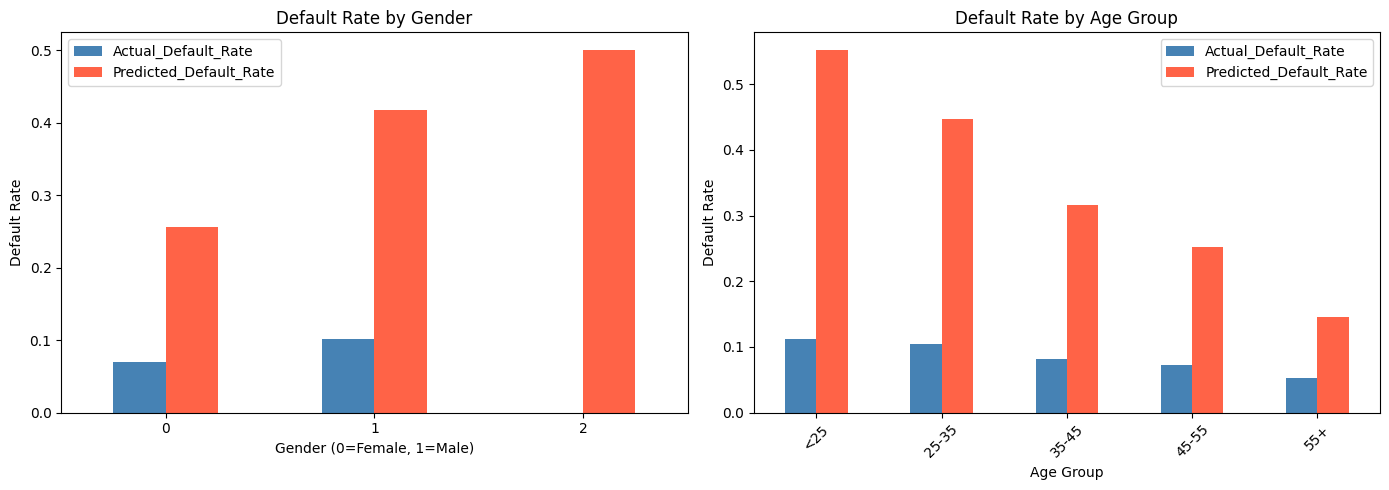

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender bias
gender_bias[['Actual_Default_Rate', 'Predicted_Default_Rate']].plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato']
)
axes[0].set_title('Default Rate by Gender')
axes[0].set_xlabel('Gender (0=Female, 1=Male)')
axes[0].set_ylabel('Default Rate')
axes[0].tick_params(axis='x', rotation=0)

# Age bias
age_bias[['Actual_Default_Rate', 'Predicted_Default_Rate']].plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato']
)
axes[1].set_title('Default Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Default Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
pred_probs = xgb.predict_proba(X_test)[:, 1]

defaults = pred_probs[y_test.values == 1]
non_defaults = pred_probs[y_test.values == 0]

ks_stat, ks_pvalue = ks_2samp(defaults, non_defaults)

print("=== KS Stability Test ===")
print(f"KS Statistic: {ks_stat:.4f}")
print(f"KS P-Value: {ks_pvalue:.6f}")
print()
if ks_stat >= 0.4:
    print("Model Stability: EXCELLENT ✅")
elif ks_stat >= 0.3:
    print("Model Stability: GOOD ✅")
elif ks_stat >= 0.2:
    print("Model Stability: ACCEPTABLE ⚠️")
else:
    print("Model Stability: POOR ❌")

=== KS Stability Test ===
KS Statistic: 0.3832
KS P-Value: 0.000000

Model Stability: GOOD ✅


In [9]:
print("Running 5-Fold Cross Validation...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scale_cv = (y_tr == 0).sum() / (y_tr == 1).sum()

    model = XGBClassifier(
        n_estimators=100,
        scale_pos_weight=scale_cv,
        random_state=42,
        eval_metric='auc',
        n_jobs=-1
    )
    model.fit(X_tr, y_tr)

    score = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    cv_scores.append(score)
    print(f"Fold {fold+1}: ROC-AUC = {score:.4f}")

print(f"\nMean ROC-AUC: {np.mean(cv_scores):.4f}")
print(f"Std Dev: {np.std(cv_scores):.4f}")
print(f"\nModel is {'STABLE ✅' if np.std(cv_scores) < 0.01 else 'ACCEPTABLE ✅'}")

Running 5-Fold Cross Validation...
Fold 1: ROC-AUC = 0.7395
Fold 2: ROC-AUC = 0.7465
Fold 3: ROC-AUC = 0.7391
Fold 4: ROC-AUC = 0.7491
Fold 5: ROC-AUC = 0.7385

Mean ROC-AUC: 0.7426
Std Dev: 0.0044

Model is STABLE ✅


In [10]:
print("=== Bias & Stability Summary ===")
print(f"\nKS Statistic: {ks_stat:.4f}")
print(f"\nCross Validation ROC-AUC:")
print(f"  Mean:    {np.mean(cv_scores):.4f}")
print(f"  Std Dev: {np.std(cv_scores):.4f}")
print(f"  Min:     {np.min(cv_scores):.4f}")
print(f"  Max:     {np.max(cv_scores):.4f}")
print(f"\nGender Bias:")
print(gender_bias[['Actual_Default_Rate', 'Predicted_Default_Rate']])
print(f"\nAge Bias:")
print(age_bias[['Actual_Default_Rate', 'Predicted_Default_Rate']])
print("\nBias & Stability Analysis Complete! ✅")

=== Bias & Stability Summary ===

KS Statistic: 0.3832

Cross Validation ROC-AUC:
  Mean:    0.7426
  Std Dev: 0.0044
  Min:     0.7385
  Max:     0.7491

Gender Bias:
             Actual_Default_Rate  Predicted_Default_Rate
CODE_GENDER                                             
0                         0.0699                  0.2560
1                         0.1017                  0.4181
2                         0.0000                  0.5000

Age Bias:
           Actual_Default_Rate  Predicted_Default_Rate
AGE_GROUP                                             
<25                     0.1127                  0.5512
25-35                   0.1051                  0.4472
35-45                   0.0809                  0.3163
45-55                   0.0718                  0.2518
55+                     0.0530                  0.1449

Bias & Stability Analysis Complete! ✅
